# Preparación

In [18]:
from data_dlwd import get_simem_data
import pandas as pd

In [19]:
df_generacion = get_simem_data('E17D25', '2025-01-01', '2025-12-31')
df_costo_mdd = get_simem_data('03e35f', '2025-01-01', '2025-12-31')
df_demanda_real = get_simem_data('9b0967', '2025-01-01', '2025-12-31')
df_aportes = get_simem_data('2bff14', '2025-01-01', '2025-12-31')
df_capacidad_plantas = get_simem_data('FADED0', '2026-06-22', '2026-06-27')
df_costo_plantas = get_simem_data('b1189f', '2026-05-27', '2026-06-27')

Dataset FADED0: 2400 registros, 10 columnas
Dataset E17D25: 151468 registros, 8 columnas
Dataset 03e35f: 8760 registros, 3 columnas
Dataset 9b0967: 255942 registros, 8 columnas
Dataset 2bff14: 16201 registros, 9 columnas
Dataset b1189f: 19680 registros, 7 columnas


In [69]:
tipo_por_planta = (df_generacion.groupby('CodigoPlanta')['TipoGeneracion']
                   .first()
                   .reset_index())

costo_por_planta = (df_costo_plantas.groupby('CodigoPlanta')['Valor']
                    .mean()
                    .reset_index())
costo_por_planta.columns = ['CodigoPlanta', 'CostoOferta']

costo_por_planta = costo_por_planta.merge(tipo_por_planta, on='CodigoPlanta', how='left')

# Costo promedio por tipo
print(costo_por_planta.groupby('TipoGeneracion')['CostoOferta'].describe())

                count        mean         std      min       25%         50%  \
TipoGeneracion                                                                 
Hidraulica       30.0  331.213647  333.023752  84.6716   94.4922  170.957600   
Solar            12.0   83.958917    3.324260  79.3276   80.6716   84.834800   
Termica          40.0  793.950441  658.767521  87.0216  256.9226  729.269121   

                       75%        max  
TipoGeneracion                         
Hidraulica       405.77860  1142.6716  
Solar             85.50120    88.6798  
Termica         1164.13465  2873.2126  


In [70]:
capacidad_max = df_capacidad_plantas.merge(tipo_por_planta, on='CodigoPlanta', how='left')

capacidad_por_tipo = (capacidad_max.groupby('TipoGeneracion')['Valor']
                      .sum() * 24 / 1e6)  # en GWh

print(capacidad_por_tipo)

TipoGeneracion
Cogenerador      18.480000
Eolica            3.936000
Hidraulica     1270.384032
Solar           297.979402
Termica         579.429120
Name: Valor, dtype: float64


In [71]:
df_generacion['Fecha'] = pd.to_datetime(df_generacion['Fecha'])
df_costo_mdd['FechaHora'] = pd.to_datetime(df_costo_mdd['FechaHora'])
df_demanda_real['Fecha'] = pd.to_datetime(df_demanda_real['Fecha'])
df_aportes['Fecha'] = pd.to_datetime(df_aportes['Fecha'])

df_demanda = df_demanda_real[df_demanda_real['CodigoVariable'] == 'DdaReal'].copy()
df_perdidas = df_demanda_real[df_demanda_real['CodigoVariable'] == 'PerdidasEnergia'].copy()

print(f"Demanda: {df_demanda.shape[0]} registros")
print(f"Pérdidas: {df_perdidas.shape[0]} registros")

Demanda: 127971 registros
Pérdidas: 127971 registros


# Análisis

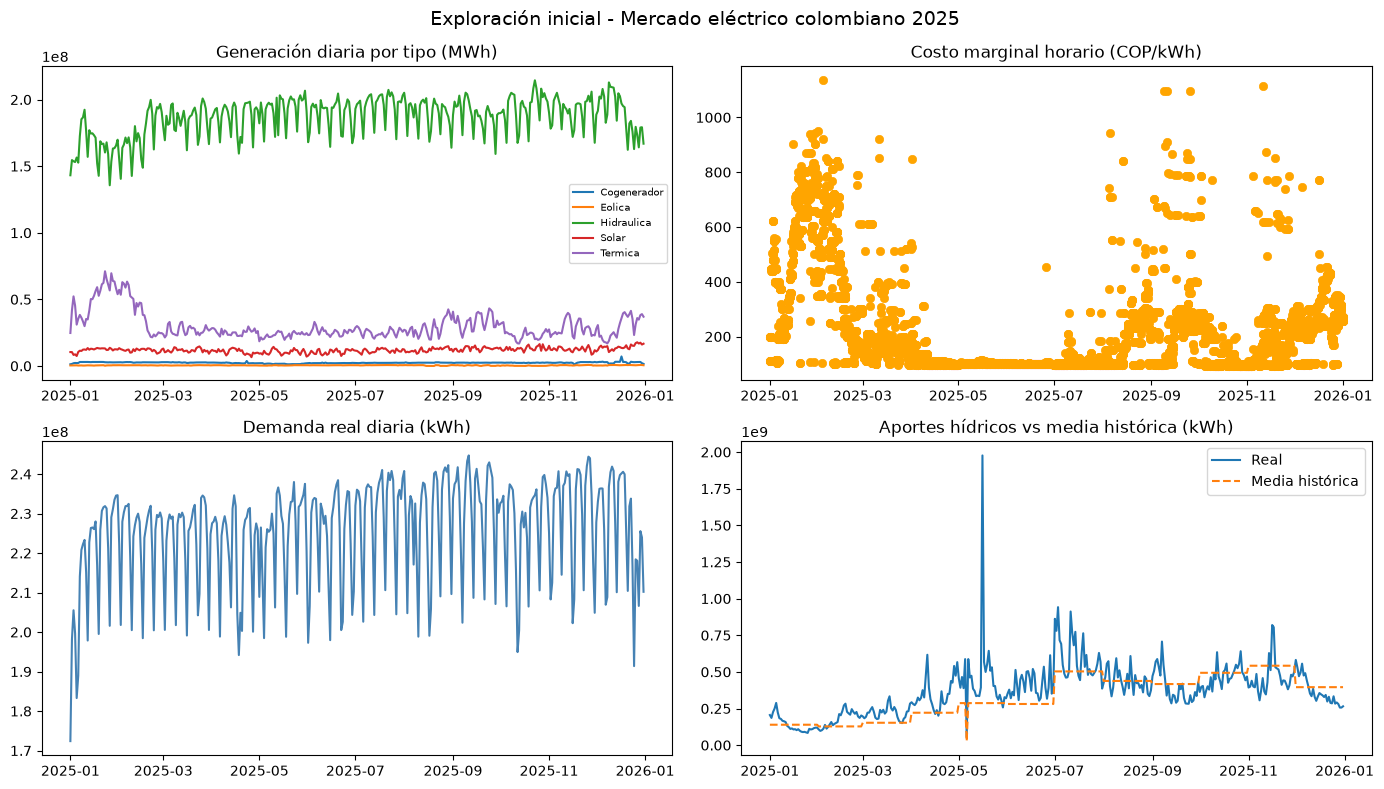

In [72]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Exploración inicial - Mercado eléctrico colombiano 2025', fontsize=14)

# 1. Generación total diaria por tipo
gen_diaria = df_generacion.groupby(['Fecha', 'TipoGeneracion'])['GeneracionRealEstimada'].sum().reset_index()
for tipo in gen_diaria['TipoGeneracion'].unique():
    subset = gen_diaria[gen_diaria['TipoGeneracion'] == tipo]
    axes[0,0].plot(subset['Fecha'], subset['GeneracionRealEstimada'], label=tipo)
axes[0,0].set_title('Generación diaria por tipo (MWh)')
axes[0,0].legend(fontsize=7)

# 2. Costo marginal horario
axes[0,1].scatter(df_costo_mdd['FechaHora'], df_costo_mdd['CostoMarginalRedespacho'], color='orange', linewidth=0.5)
axes[0,1].set_title('Costo marginal horario (COP/kWh)')

# 3. Demanda total diaria
demanda_diaria = df_demanda.groupby('Fecha')['Valor'].sum().reset_index()
axes[1,0].plot(demanda_diaria['Fecha'], demanda_diaria['Valor'], color='steelblue')
axes[1,0].set_title('Demanda real diaria (kWh)')

# 4. Aportes hídricos vs media histórica
aportes_diarios = df_aportes.groupby('Fecha')[['AportesHidricosEnergia', 'MediaHistoricaEnergia']].sum().reset_index()
axes[1,1].plot(aportes_diarios['Fecha'], aportes_diarios['AportesHidricosEnergia'], label='Real')
axes[1,1].plot(aportes_diarios['Fecha'], aportes_diarios['MediaHistoricaEnergia'], label='Media histórica', linestyle='--')
axes[1,1].set_title('Aportes hídricos vs media histórica (kWh)')
axes[1,1].legend()

plt.tight_layout()
plt.show()

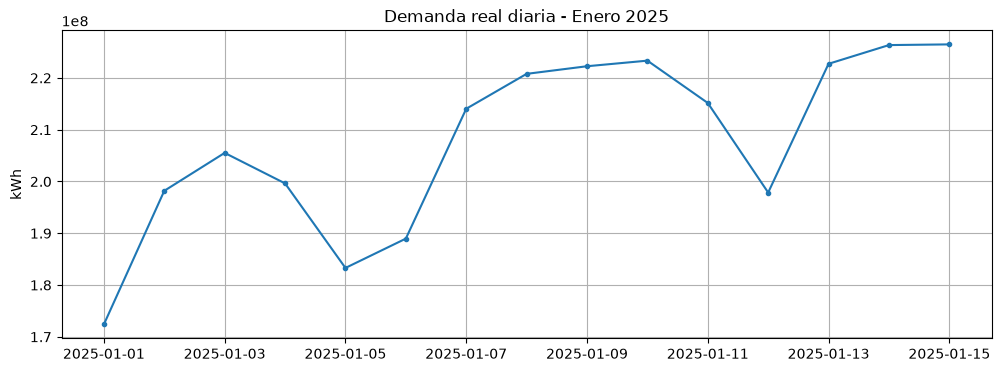

In [73]:
mask = (demanda_diaria['Fecha'] >= '2025-01-01') & (demanda_diaria['Fecha'] <= '2025-01-15')
demanda_enero = demanda_diaria[mask]

plt.figure(figsize=(12, 4))
plt.plot(demanda_enero['Fecha'], demanda_enero['Valor'], marker='o', markersize=3)
plt.title('Demanda real diaria - Enero 2025')
plt.ylabel('kWh')
plt.grid(True)
plt.show()

Hay una oscilación a lo largo de todo el año, mostrando mínimos en los fines de semana, en especial los domingos. La primera y las dos últimas semanas del año tienen una demanda menor a la tendencia del resto del año.

In [74]:
# Generación diaria por tipo
gen_tipo = df_generacion.groupby(['Fecha', 'TipoGeneracion'])['GeneracionRealEstimada'].sum().unstack(fill_value=0).reset_index()

# Costo marginal - promedio diario
costo_diario = df_costo_mdd.copy()
costo_diario['Fecha'] = pd.to_datetime(df_costo_mdd['FechaHora'].dt.date)
costo_diario = costo_diario.groupby('Fecha')['CostoMarginalRedespacho'].mean().reset_index()

# Demanda diaria nacional
demanda_diaria_total = df_demanda.groupby('Fecha')['Valor'].sum().reset_index()
demanda_diaria_total.columns = ['Fecha', 'DemandaTotal']

# Aportes diarios nacionales
aportes_diarios_total = df_aportes.groupby('Fecha')[['AportesHidricosEnergia', 'MediaHistoricaEnergia']].sum().reset_index()

# Unir todo
df_master = gen_tipo.merge(costo_diario, on='Fecha')
df_master = df_master.merge(demanda_diaria_total, on='Fecha')
df_master = df_master.merge(aportes_diarios_total, on='Fecha')

print(df_master.shape)
print(df_master.columns.tolist())

(365, 10)
['Fecha', 'Cogenerador', 'Eolica', 'Hidraulica', 'Solar', 'Termica', 'CostoMarginalRedespacho', 'DemandaTotal', 'AportesHidricosEnergia', 'MediaHistoricaEnergia']


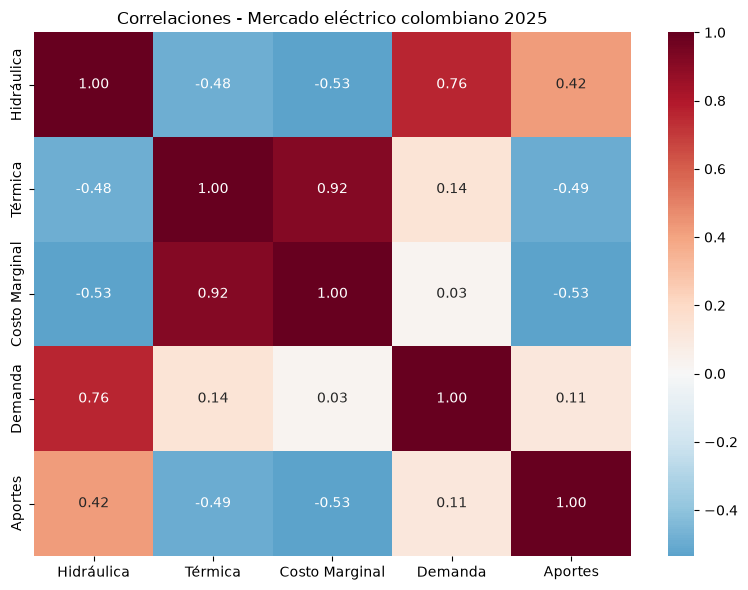

In [75]:
import seaborn as sns

# Seleccionar columnas numéricas relevantes
cols = ['Hidraulica', 'Termica', 'CostoMarginalRedespacho', 
        'DemandaTotal', 'AportesHidricosEnergia']

corr = df_master[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=['Hidráulica', 'Térmica', 'Costo Marginal', 'Demanda', 'Aportes'],
            yticklabels=['Hidráulica', 'Térmica', 'Costo Marginal', 'Demanda', 'Aportes'])
plt.title('Correlaciones - Mercado eléctrico colombiano 2025')
plt.tight_layout()
plt.show()

# Modelo

Hidro + Térmica + Otras >= Demanda

Hidro <= Aportes hídricos disponibles

Térmica <= Capacidad máxima térmica

Hidro, térmica >= 0

In [76]:
import importlib
import modelo
importlib.reload(modelo)
from modelo import calcular_costos, calcular_capacidades, despacho_optimo, correr_anio

In [77]:
costos = calcular_costos(costo_por_planta)
CAP    = calcular_capacidades(capacidad_max)
df_resultados = correr_anio(df_master, costos, CAP)

In [78]:
df_resultados['fecha'] = pd.to_datetime(df_resultados['fecha'])

# Unir resultados del modelo con lo que XM realmente despachó
df_comparacion = df_resultados.merge(
    df_master[['Fecha', 'Hidraulica', 'Termica', 'Solar', 'Eolica', 'CostoMarginalRedespacho']],
    left_on='fecha', right_on='Fecha'
)

for fuente in ['Hidraulica', 'Termica', 'Solar', 'Eolica']:
    df_comparacion[f'{fuente.lower()}_real_GWh'] = df_comparacion[fuente] / 1e6

# Diferencias modelo vs real
df_comparacion['diff_termica'] = df_comparacion['termica_real_GWh'] - df_comparacion['termica_GWh']

# Costo estimado real de XM
df_comparacion['costo_real_estimado'] = (
    df_comparacion['hidraulica_real_GWh'] * 1e6 * costos['hidro'] +
    df_comparacion['termica_real_GWh']    * 1e6 * costos['termica'] +
    df_comparacion['solar_real_GWh']      * 1e6 * costos['solar'] +
    df_comparacion['eolica_real_GWh']     * 1e6 * costos['eolica']
)

df_comparacion['ahorro'] = df_comparacion['costo_real_estimado'] - df_comparacion['costo_total']

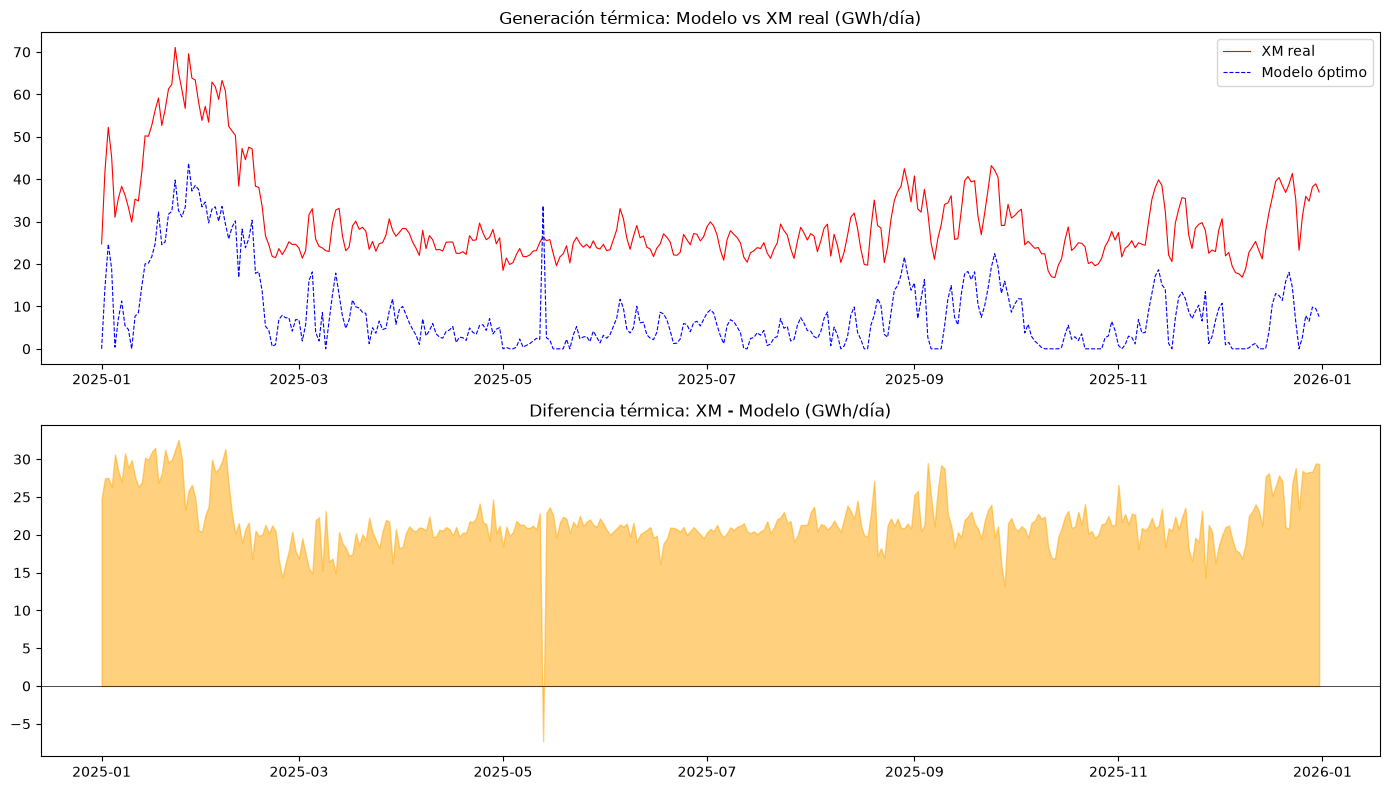

In [79]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Térmica: modelo vs real
axes[0].plot(df_comparacion['fecha'], df_comparacion['termica_real_GWh'], 
             label='XM real', color='red', linewidth=0.8)
axes[0].plot(df_comparacion['fecha'], df_comparacion['termica_GWh'], 
             label='Modelo óptimo', color='blue', linewidth=0.8, linestyle='--')
axes[0].set_title('Generación térmica: Modelo vs XM real (GWh/día)')
axes[0].legend()

# Diferencia
axes[1].fill_between(df_comparacion['fecha'], df_comparacion['diff_termica'], 
                     alpha=0.5, color='orange')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Diferencia térmica: XM - Modelo (GWh/día)')

plt.tight_layout()
plt.show()

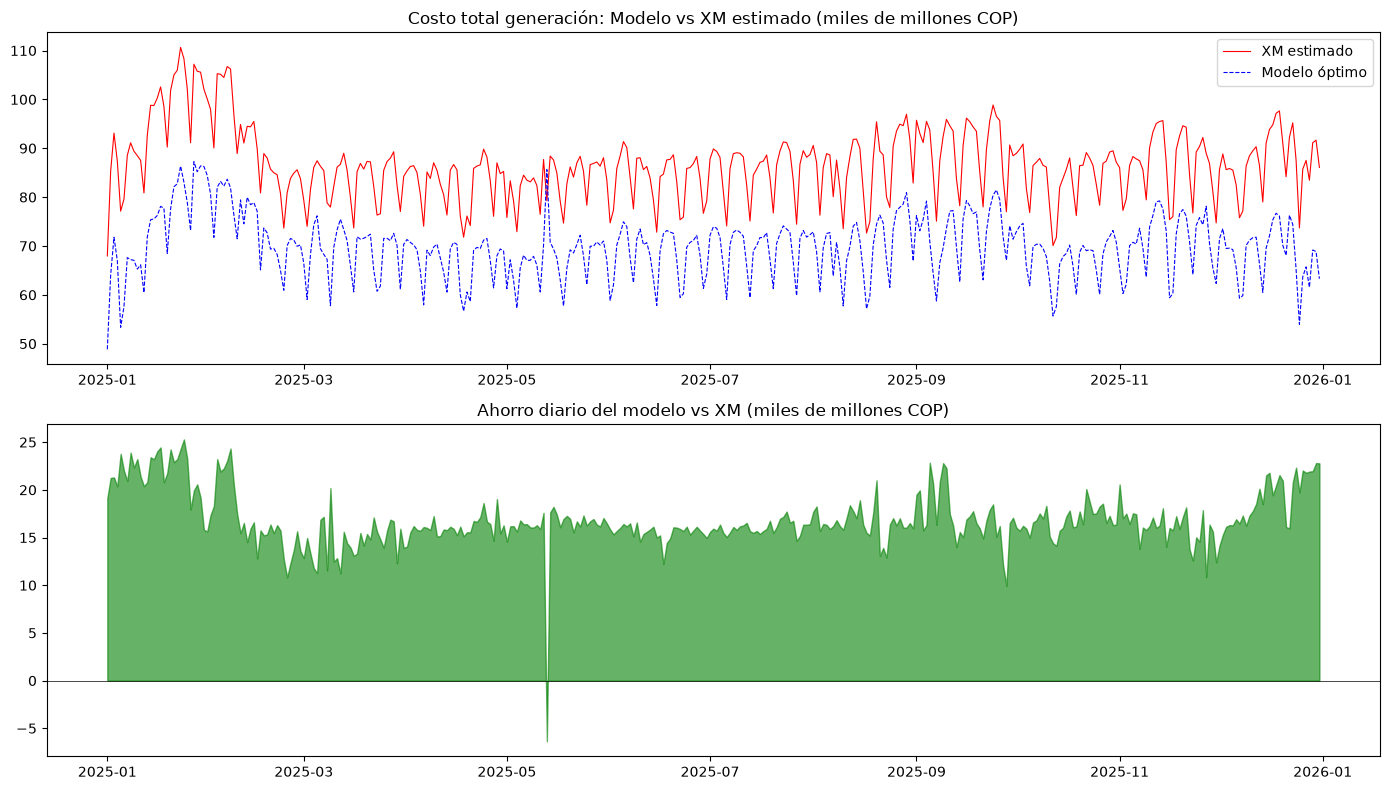

In [80]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Costo total modelo vs estimado real
axes[0].plot(df_comparacion['fecha'], df_comparacion['costo_real_estimado']/1e9, 
             label='XM estimado', color='red', linewidth=0.8)
axes[0].plot(df_comparacion['fecha'], df_comparacion['costo_total']/1e9, 
             label='Modelo óptimo', color='blue', linewidth=0.8, linestyle='--')
axes[0].set_title('Costo total generación: Modelo vs XM estimado (miles de millones COP)')
axes[0].legend()

# Ahorro diario
axes[1].fill_between(df_comparacion['fecha'], df_comparacion['ahorro']/1e9, 
                     alpha=0.6, color='green')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('Ahorro diario del modelo vs XM (miles de millones COP)')

plt.tight_layout()
plt.show()

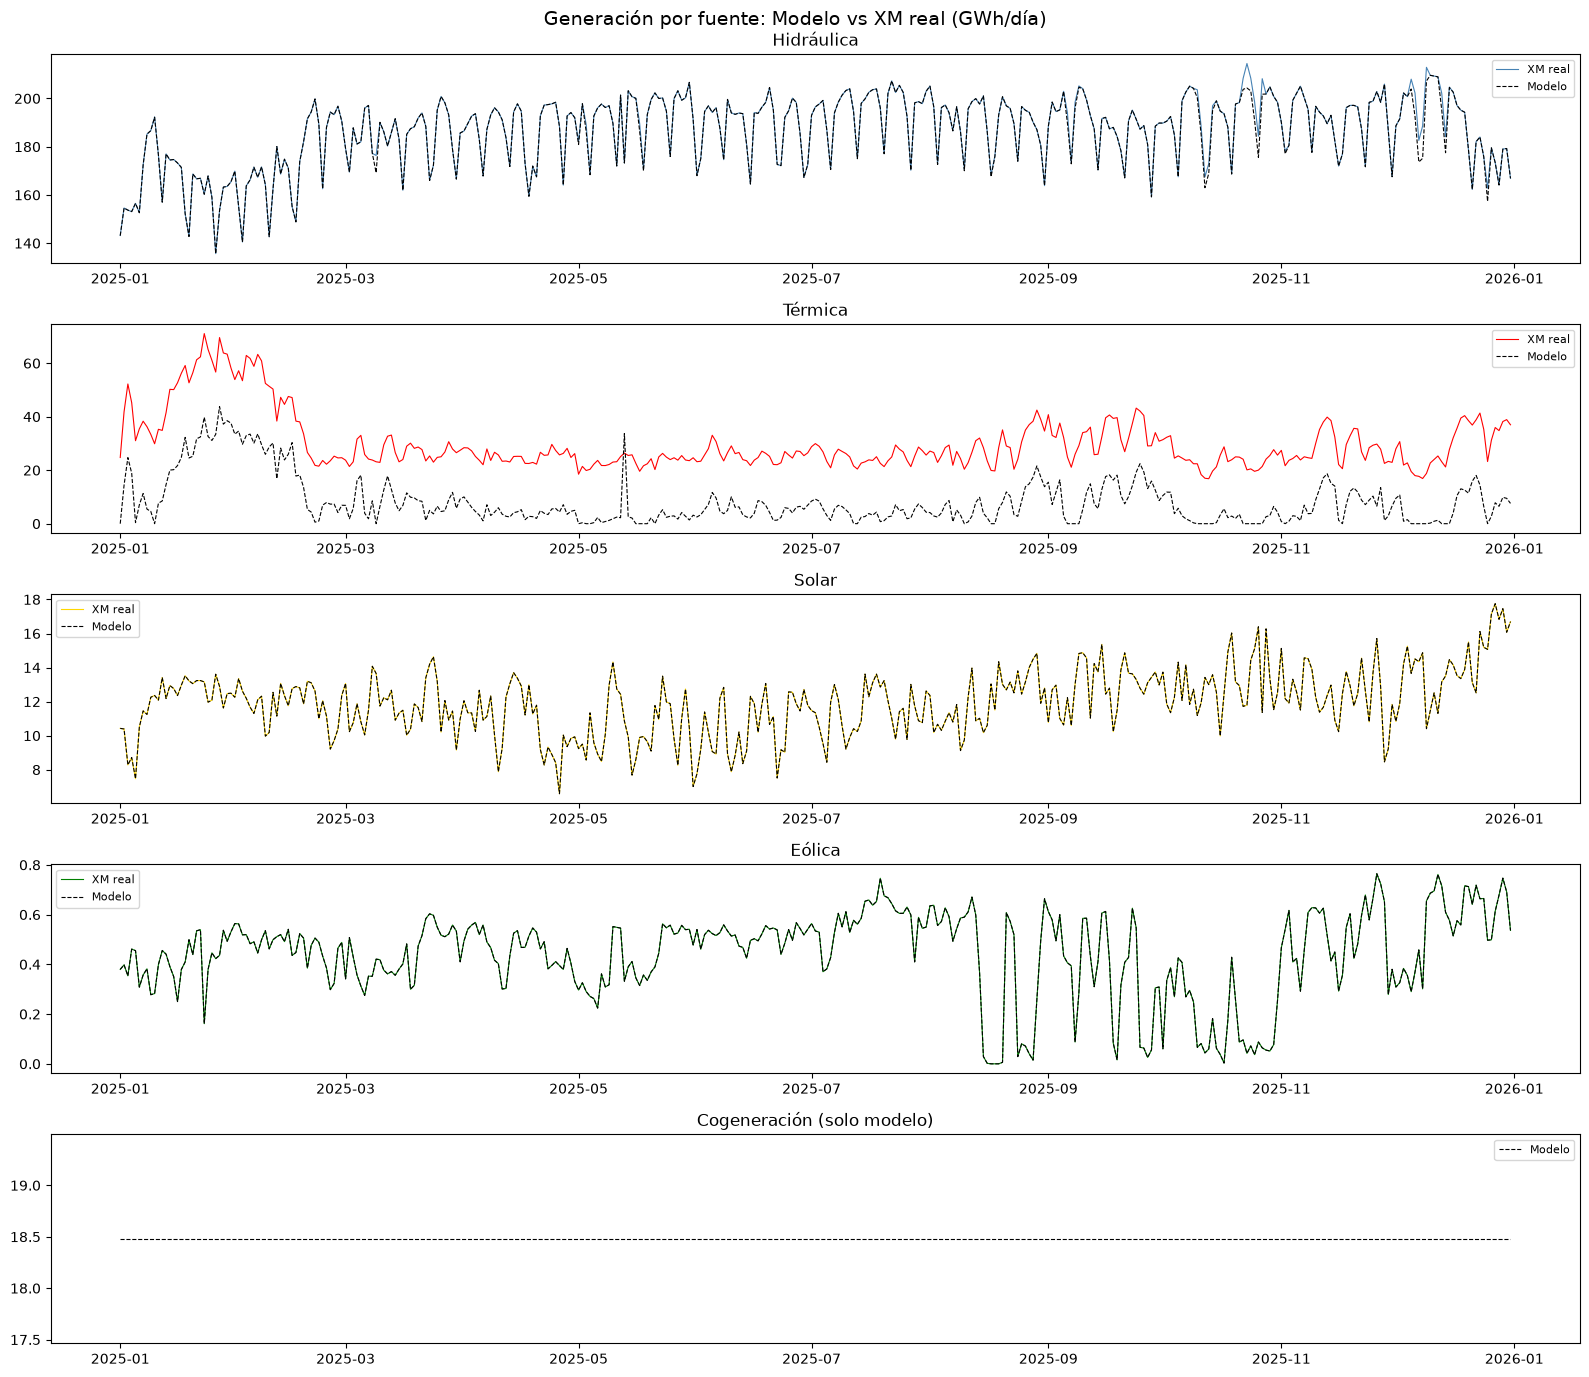

In [81]:
fig, axes = plt.subplots(5, 1, figsize=(16, 14))
fig.suptitle('Generación por fuente: Modelo vs XM real (GWh/día)', fontsize=14)

fuentes = [
    ('hidro_GWh', 'hidraulica_real_GWh', 'Hidráulica', 'steelblue'),
    ('termica_GWh', 'termica_real_GWh', 'Térmica', 'red'),
    ('solar_GWh', 'solar_real_GWh', 'Solar', 'gold'),
    ('eolica_GWh', 'eolica_real_GWh', 'Eólica', 'green'),
    ('cogen_GWh', None, 'Cogeneración (solo modelo)', 'purple'),
]

for idx, (modelo_col, real_col, titulo, color) in enumerate(fuentes):
    ax = axes[idx]
    if real_col:
        ax.plot(df_comparacion['fecha'], df_comparacion[real_col], 
                label='XM real', color=color, linewidth=0.8)
    ax.plot(df_comparacion['fecha'], df_comparacion[modelo_col], 
            label='Modelo', color='black', linewidth=0.8, linestyle='--')
    ax.set_title(titulo)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()